In [1]:
import xarray as xr
import pandas as pd
import cartopy as ctpy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patheffects as pe
import matplotlib.lines as mlines
import seaborn as sns
import importlib
import glob
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import metpy.calc as mpcalc
import scipy.stats as stat
import nctoolkit as nc
import xcdat
import pickle
import dask.array as da
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from numpy import *
from netCDF4 import Dataset
from datetime import datetime, timedelta
from metpy.units import units
from metpy.calc import heat_index
from metpy.units import units
import json
import math
import sys

import filepaths as filepaths
import model_preprocess as model_prep
import calculations as dr_g_calcs
import dictionary as dicts
importlib.reload(filepaths)
importlib.reload(model_prep)
importlib.reload(dr_g_calcs)
importlib.reload(dicts)


nctoolkit is using Climate Data Operators version 2.0.5


2026-07-21 09:38:00,087 [WARNING]: registry.py(_helper_single_adder:493) >> Redefining 'percent' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
2026-07-21 09:38:00,087 [WARNING]: registry.py(_helper_single_adder:493) >> Redefining 'percent' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
2026-07-21 09:38:00,092 [WARNING]: registry.py(_helper_single_adder:493) >> Redefining '%' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
2026-07-21 09:38:00,092 [WARNING]: registry.py(_helper_single_adder:493) >> Redefining '%' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
2026-07-21 09:38:00,098 [WARNING]: registry.py(_helper_single_adder:493) >> Redefining 'year' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
2026-07-21 09:38:00,098 [WARNING]: registry.py(_helper_single_adder:493) >> Redefining 'year' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
2026-07-21 09:38:00,099 [WARNING]: registry.py(_helper_single_ad

<module 'dictionary' from '/home/rgaal/notebooks/newer_stuff/dictionary.py'>

In [8]:
yr_i=2015
yr_f=2024
var_choice='pr'
label_choice='pr_mm'
wrf_var='RAINNC'
plot_var='Precipitation'

timeframe_label='Future'
timeframe='future'

timeframe_array=['Annual','DJF','MAM','JJA','SON']
location_strs=['South Florida']
location_abbrevs=['South FL']
so_fl_ll=[25.,-82.]
so_fl_ur=[27.,-80.]
locations=[so_fl_ll,so_fl_ur]
lat_arr=array(locations)[:,0]
lon_arr=array(locations)[:,1]

In [3]:
model_array = ['CAM-MPAS-HR','CMCC-CM2-VHR4','FGOALS-f3-H','ECMWF-IFS-HR','HiRAM-SIT-HR','MRI-AGCM3-2-S']
informal_array_highresmip=['cam-mpas','cmcc','fgoals','ecmwf','hiram','mri']
informal_array_downscale=['cesm2','cnrm','hadgem3-mm','hadgem3-ll','ipsl','miroc6','mpi']
downscale_array = ['CESM2-LENS','CNRM-CM6-1','HadGEM3-GC31-MM','HadGEM3-GC31-LL','IPSL-CM6A-LR','MIROC6','MPI-ESM1-2-HR']
calc_arr=['mae','bias','std_dev']

load pickle files for highresmip and change dtype for plotting

In [36]:
if (timeframe=='historical'):
    with open('/bkirtman/rgaal/heatmap_extra_historical_highresmip_wetszn.pkl', 'rb') as file:
        # Load the data from the file
        cmip_dict = pickle.load(file)

else:    
    with open('/bkirtman/rgaal/heatmap_extra_future_highresmip_wetszn.pkl', 'rb') as file:
        # Load the data from the file
        cmip_dict = pickle.load(file)

In [20]:
cmip_dict['group_category'] = cmip_dict['group_category'].str.replace('_', '-', regex=False)
cmip_dict['group_category'] = cmip_dict['group_category'].astype(str)
cmip_dict['model'] = cmip_dict['model'].astype(str)
cmip_dict['mae'] = cmip_dict['mae'].astype(float)
cmip_dict['bias'] = cmip_dict['bias'].astype(float)
cmip_dict['std_dev'] = cmip_dict['std_dev'].astype(float)

load pickle files for downscaled data and change dtype for plotting

In [25]:
with open('/bkirtman/rgaal/heatmap_extra_'+timeframe+'_loca_wetszn.pkl', 'rb') as file:
    # Load the data from the file
    loca_dict1 = pickle.load(file)

with open('/bkirtman/rgaal/heatmap_extra_'+timeframe+'_bccaq_wetszn.pkl', 'rb') as file:
    # Load the data from the file
    bccaq_dict1 = pickle.load(file)

with open('/bkirtman/rgaal/heatmap_extra_'+timeframe+'_gddp_wetszn.pkl', 'rb') as file:
    # Load the data from the file
    gddp_dict1 = pickle.load(file)

full_dict=pd.concat([loca_dict1,bccaq_dict1,gddp_dict1],ignore_index=True)
full_dict['group_category'] = full_dict['group_category'].astype(str) + time_abbrev

In [26]:
full_dict['group_category'] = full_dict['group_category'].str.replace('downscale-', '', regex=False)
full_dict['group_category'] = full_dict['group_category'].astype(str)
full_dict['model'] = full_dict['model'].astype(str)
full_dict['mae'] = full_dict['mae'].astype(float)
full_dict['bias'] = full_dict['bias'].astype(float)
full_dict['std_dev'] = full_dict['std_dev'].astype(float)

plot heatmaps (1 per timeframe)

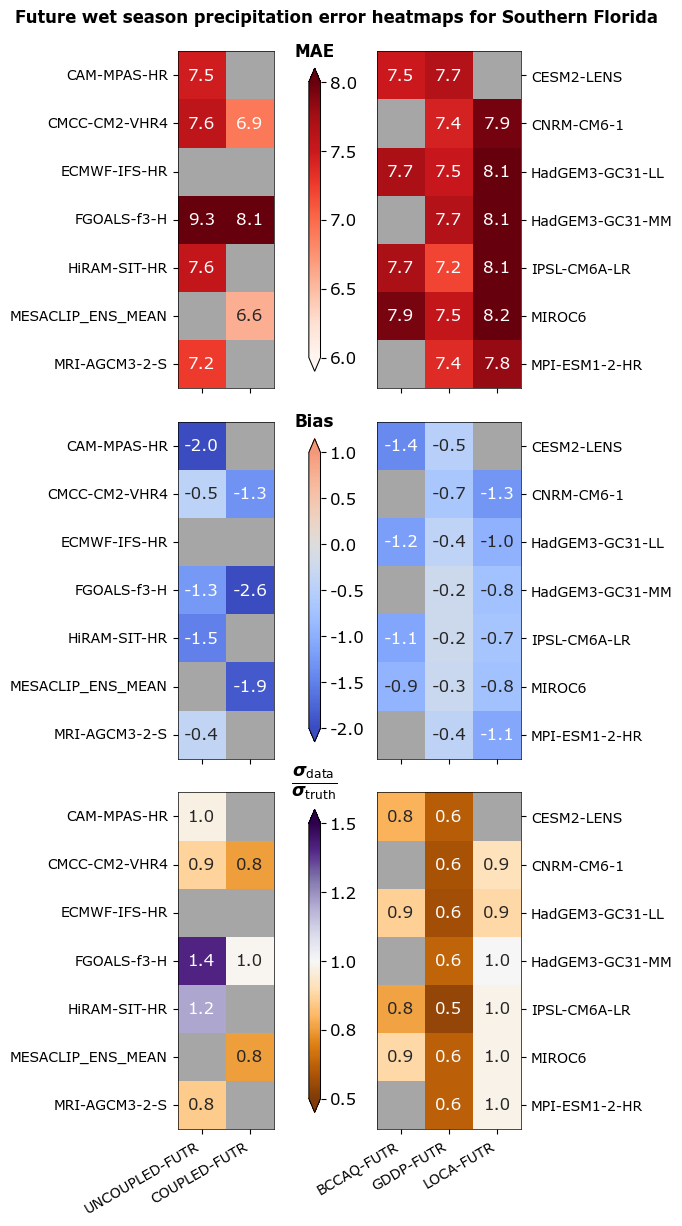

In [27]:
mpl.rcParams['font.family'] = "sans-serif"
mpl.rcParams['font.sans-serif'] = "Verdana" 
plt.rcParams['savefig.dpi'] = 300

fig, ax = plt.subplots(3, 2,figsize=(14,14),
                         gridspec_kw={'height_ratios': [10,10,10], 
                                      'width_ratios': [30,30], 
                                      'hspace':0.1,'wspace':-0.45},sharex='col',sharey=False)#hspace': -0.1
axs_flat=ax.flat
cmaps=['Reds','coolwarm','PuOr']
cbar_num=[2,5,8]
centers=[7.,0.,1.]
vmins=[6.,-2.,0.5]
vmaxs=[8.,1,1.5]
step=[0.5,0.5,0.25]
xtd=['both','both','both']

fraction_string = r'$\frac{\mathbfit{\sigma}_{\text{data}}}{\mathbfit{\sigma}_{\text{truth}}}$'
cbar_size=[12,12,18]

labels=['MAE','Bias',fraction_string]
fmts=['%.1f','%.1f','%.1f']
mask_label=[True,True,True]

stepp=0

for i,j in enumerate(calc_arr):
    pivot_df = cmip_dict.pivot(index='model', columns='group_category', values=str(j)) 
    pivot_df=pivot_df.sort_index(axis=1,ascending=False)
    pivot_df = pivot_df.round(2) 
    annot_labels = pivot_df.map(lambda val: f"{val:.1f}" if pd.notnull(val) else "X")
    
    hm=sns.heatmap(pivot_df, annot=True, fmt='.1f', ax=axs_flat[stepp+i],yticklabels=mask_label[i],center=centers[i],cbar=True,
                   linewidths=0.,linecolor='black',square=True,cmap=cmaps[i],vmin=vmins[i],vmax=vmaxs[i],#levels=arange(vmins[i],vmaxs[i]+step[i],step[i]),
                   cbar_kws={'orientation':'vertical','shrink':0.9,'extend':xtd[i],'pad':0.05,'aspect':26,'format':fmts[i],'ticks':arange(vmins[i],vmaxs[i]+step[i],step[i])},
                   annot_kws={'fontweight':'normal','fontsize':12})
    hm.collections[0].cmap.set_bad('black',alpha=0.35)
    colorbar = hm.collections[0].colorbar
    
    colorbar.outline.set_edgecolor("black")
    colorbar.outline.set_linewidth(0.75)
    cbar_ax = hm.figure.axes[-1]
    cbar_ax.tick_params(labelsize=12)  # Set font size
    cbar_ax.set_title(labels[i],size=cbar_size[i],fontweight='bold',ha='center',va='bottom')

    hm.set(xlabel="", ylabel="")
    labs=hm.get_xticklabels()
    hm.set_xticklabels([label.get_text().upper() for label in labs], fontsize=10,rotation=30.,ha='right')
    hm.set_yticklabels(hm.get_yticklabels(), fontsize=10)

    for _, spine in hm.spines.items():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(0.5)

    ###########################################
    stepp+=1
    ###########################################
    
    pivot_df = full_dict.pivot(index='model', columns='group_category', values=str(j))
    pivot_df = pivot_df.round(2) 
    annot_labels = pivot_df.map(lambda val: f"{val:.1f}" if pd.notnull(val) else "X")
    
    hm1=sns.heatmap(pivot_df, annot=True, fmt='.1f', ax=axs_flat[stepp+i],yticklabels=mask_label[i],center=centers[i],#cbar_ax=axs_flat[cbar_num[i]],
                   linewidths=0.,linecolor='black',square=True,cmap=cmaps[i],vmin=vmins[i],vmax=vmaxs[i],cbar=False,
                   cbar_kws={'orientation':'vertical','shrink':0.9,'extend':xtd[i],'pad':0.05,'aspect':26,'format':fmts[i],'ticks':arange(vmins[i],vmaxs[i]+step[i],step[i])},
                   annot_kws={'fontweight':'normal','fontsize':12})
    hm1.collections[0].cmap.set_bad('black',alpha=0.35)

    hm1.set(xlabel="", ylabel="")
    labs=hm1.get_xticklabels()
    hm1.set_xticklabels([label.get_text().upper() for label in labs], fontsize=10, rotation=30.,ha='right')
    hm1.set_yticklabels(hm1.get_yticklabels(), fontsize=10,rotation=0.)
    
    hm1.yaxis.tick_right()

    for _, spine in hm1.spines.items():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(0.5)

fig.suptitle(timeframe_label+' wet season precipitation error heatmaps for Southern Florida',size=12,y=0.91,x=0.57,fontweight='bold',ha='center')
